In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_cnn_lstm_baseline, plot_loss_vs_epoch, train_multiscale_cnn_lstm, train_cnn_lstm_attention, evaluate_cnn_lstm_vitaldb

In [3]:
WINDOW_SIZE = 625
STEP_SIZE = 625

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_0overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:02<00:00, 78.26it/s] 


Skipped recordings: 96


100%|██████████| 1200/1200 [00:16<00:00, 74.86it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:16<00:00, 71.21it/s]


Skipped recordings: 9


In [4]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (417030, 1, 625), y_train shape: (417030, 2)
X_val shape: (52650, 1, 625), y_val shape: (52650, 2)


Device: cuda
X_train: torch.Size([417030, 1, 625])
y_train: torch.Size([417030, 2])
X_val: torch.Size([52650, 1, 625])
y_val: torch.Size([52650, 2])
X_test: torch.Size([52863, 1, 625])
y_test: torch.Size([52863, 2])
Epoch 01/50 | Train Loss: 841.7571 | Val Loss: 260.4009 | Train SBP RMSE: 36.387 | Train DBP RMSE: 18.961 | Val SBP RMSE: 20.211 | Val DBP RMSE: 10.598 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 216.1961 | Val Loss: 216.9794 | Train SBP RMSE: 18.176 | Train DBP RMSE: 10.100 | Val SBP RMSE: 18.309 | Val DBP RMSE: 9.936 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 194.6605 | Val Loss: 227.0533 | Train SBP RMSE: 17.144 | Train DBP RMSE: 9.767 | Val SBP RMSE: 18.816 | Val DBP RMSE: 10.003 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 176.1610 | Val Loss: 190.3077 | Train SBP RMSE: 16.279 | Train DBP RMSE: 9.344 | Val SBP RMSE: 17.120 | Val DBP RMSE: 9.355 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 159.2351 | Val Loss: 185.2756 | Train SBP RMSE: 15.457 | Train DBP RMSE: 8.920 | Val SBP RMSE:

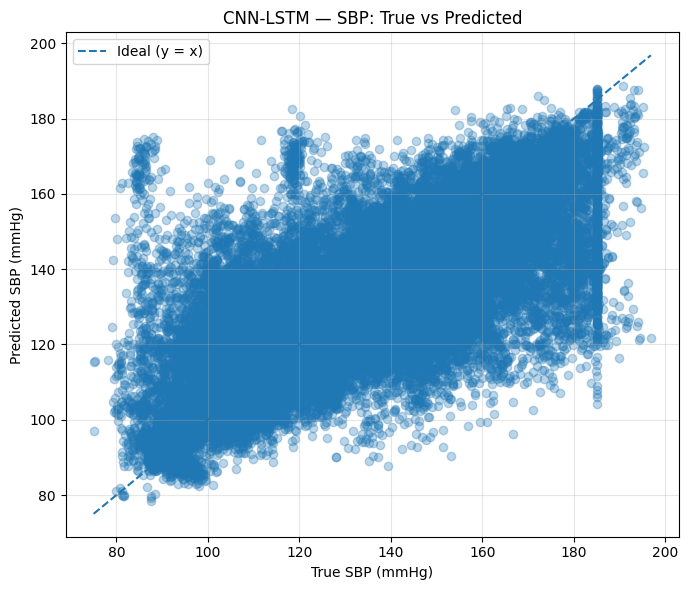

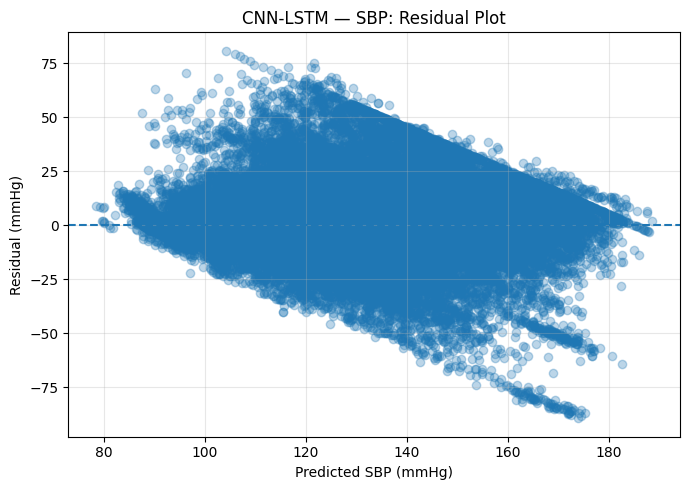

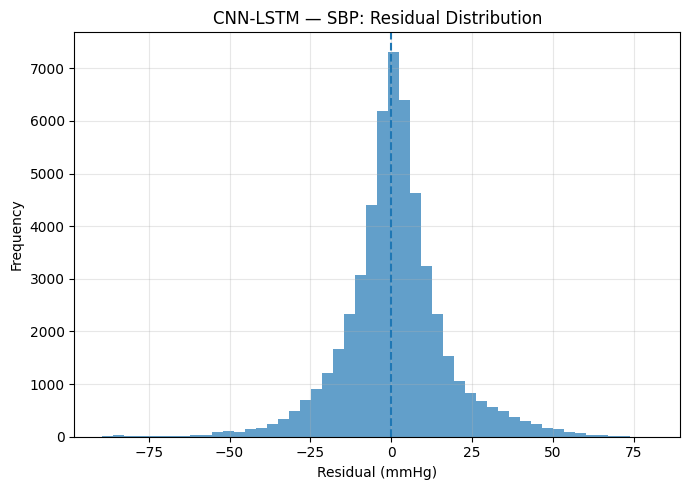

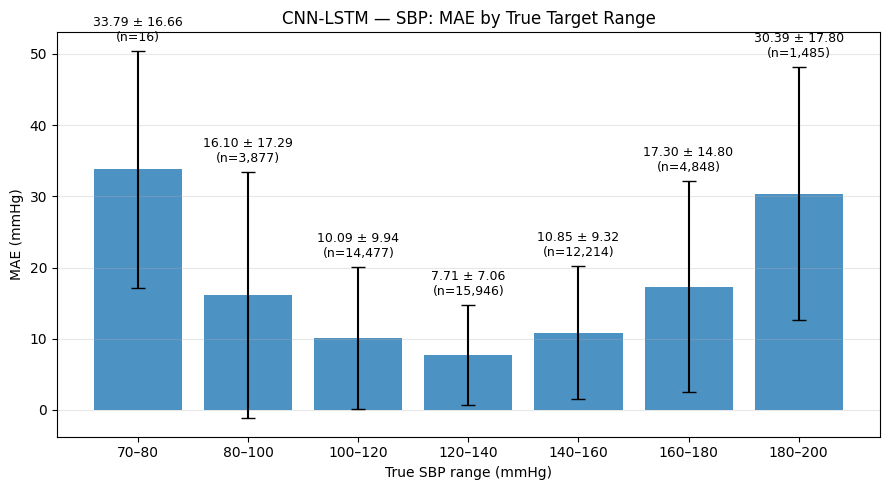

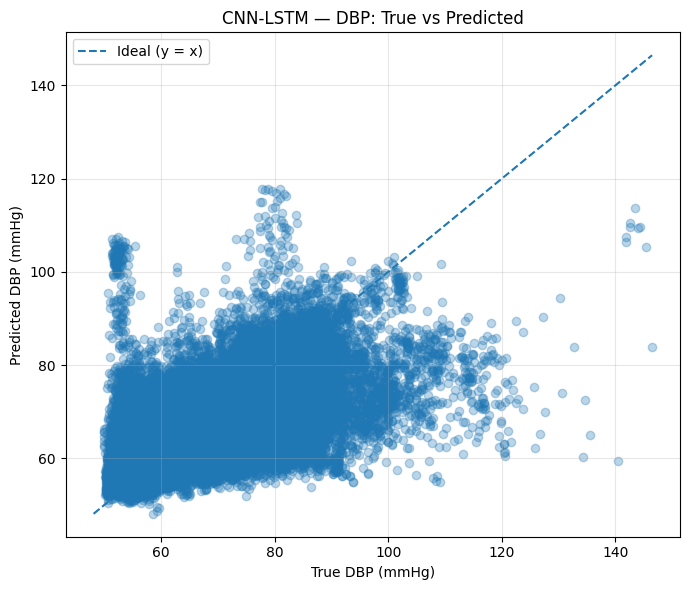

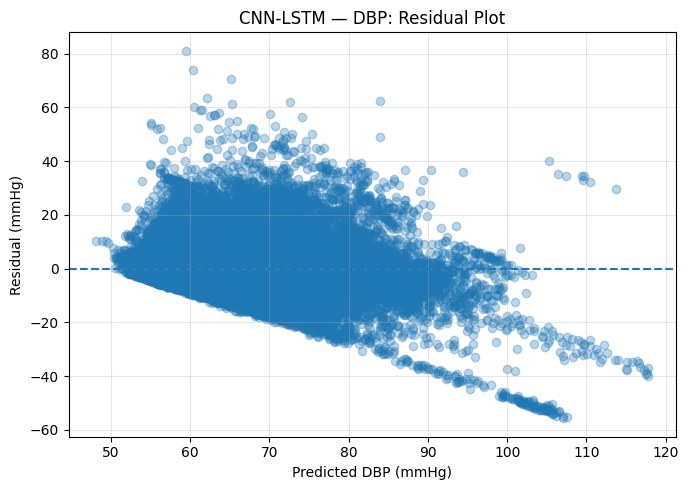

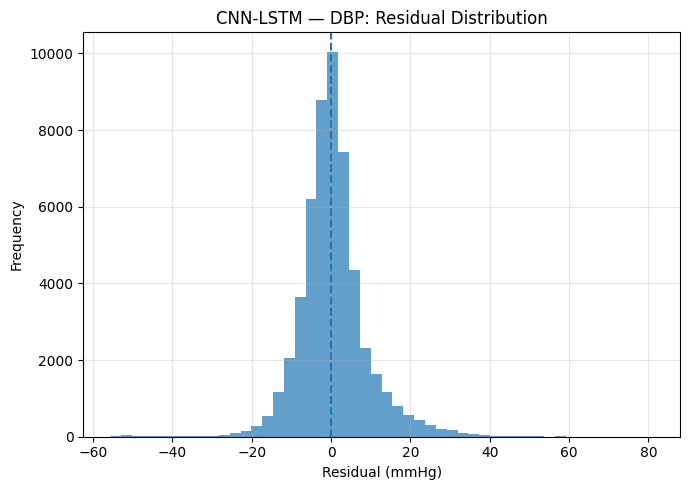

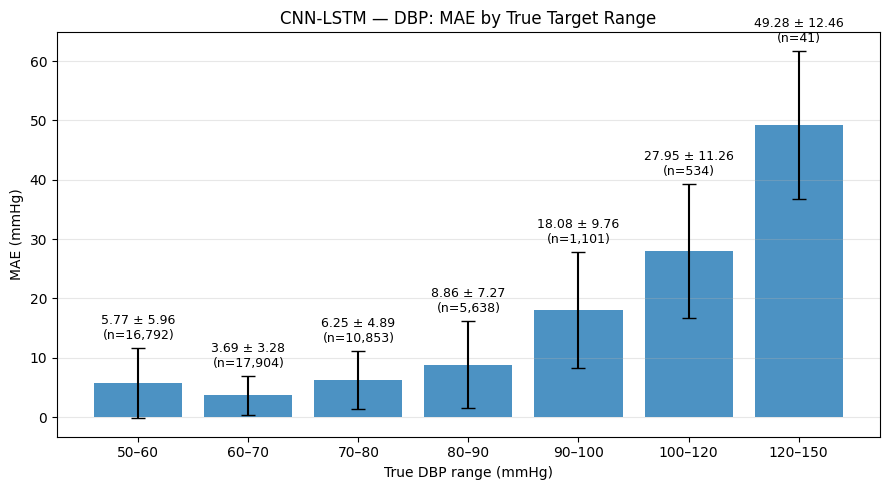

In [5]:
model_cnn_lstm, results_cnn_lstm = train_cnn_lstm_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

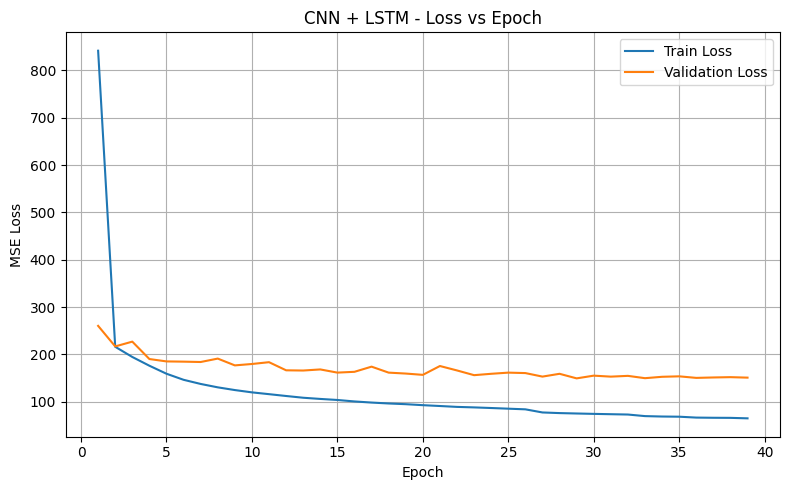

In [6]:
plot_loss_vs_epoch(
    results_cnn_lstm["history"],
    model_name="CNN + LSTM"
)

Number of VitalDB cases: 1961


CNN-LSTM VitalDB prediction: 100%|██████████| 1961/1961 [02:44<00:00, 11.95case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 26.3159
MSE : 692.5255
R²  : -0.6253
MAE : 20.8414

DBP
RMSE: 15.1480
MSE : 229.4612
R²  : -0.4098
MAE : 11.9938


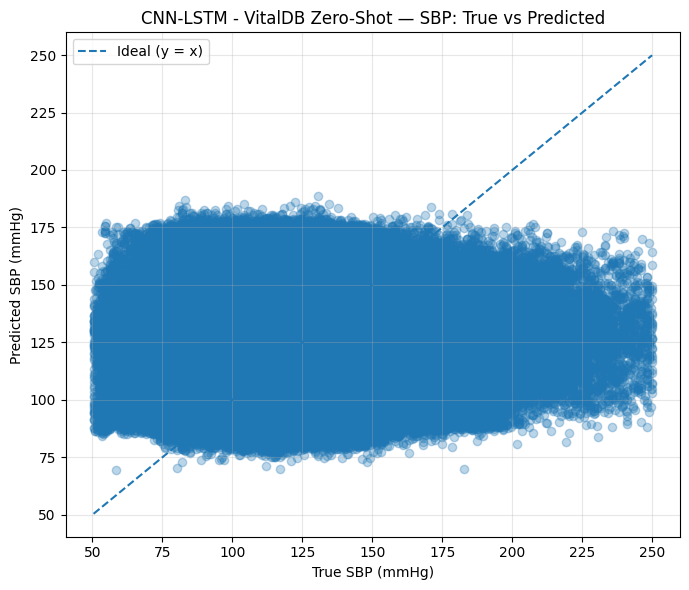

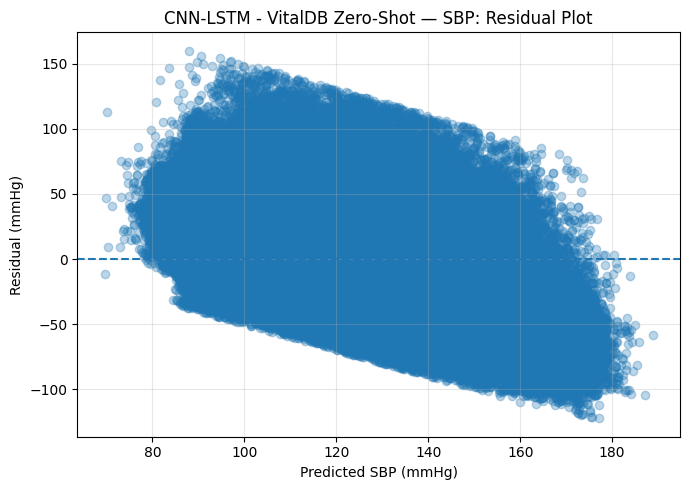

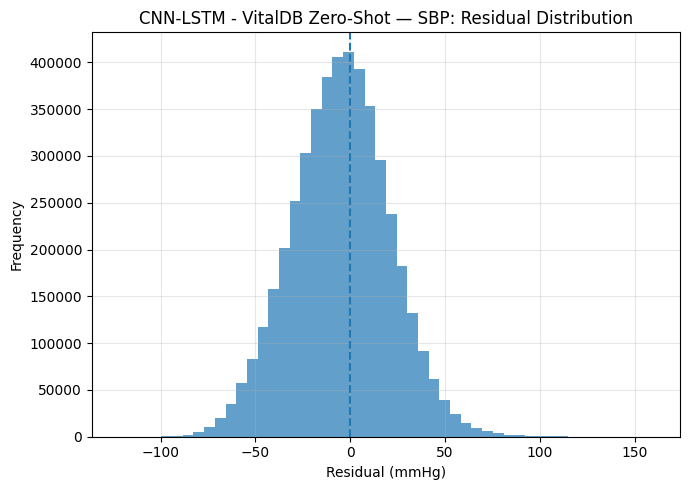

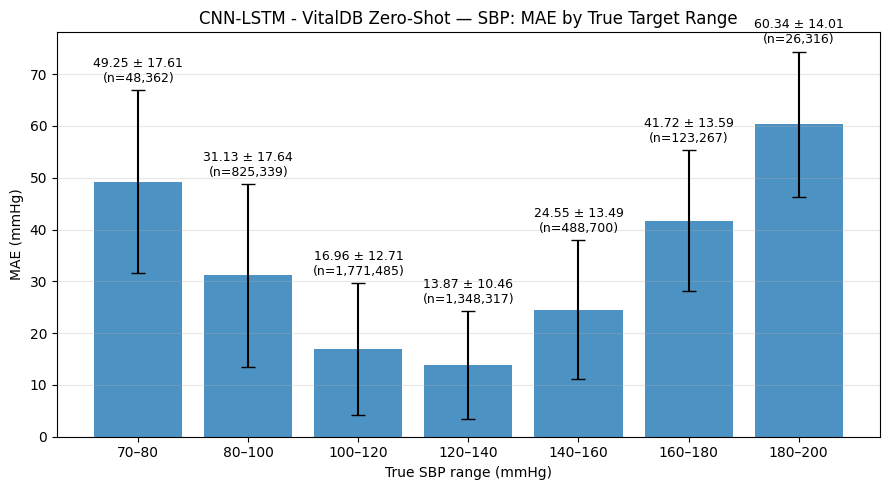

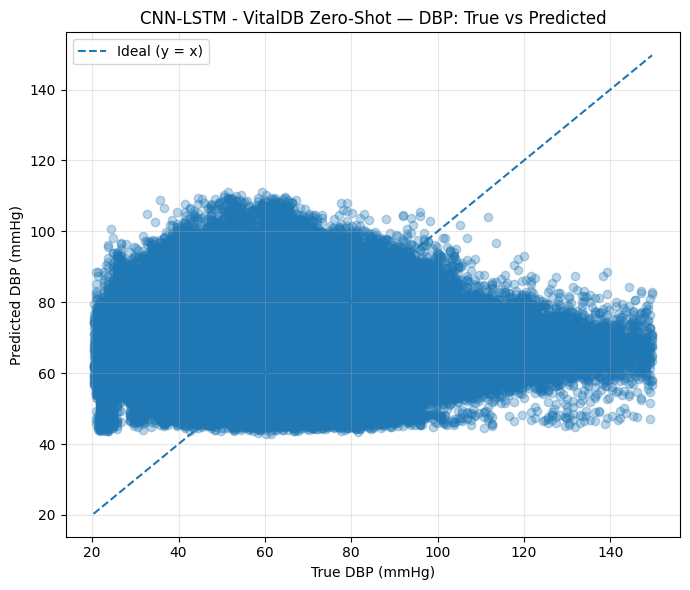

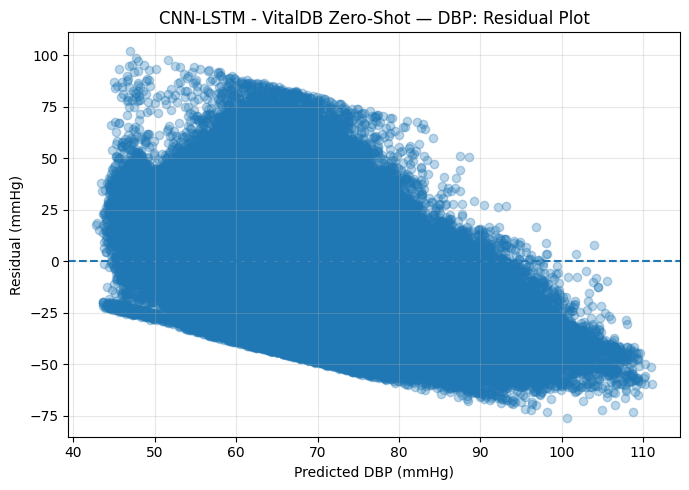

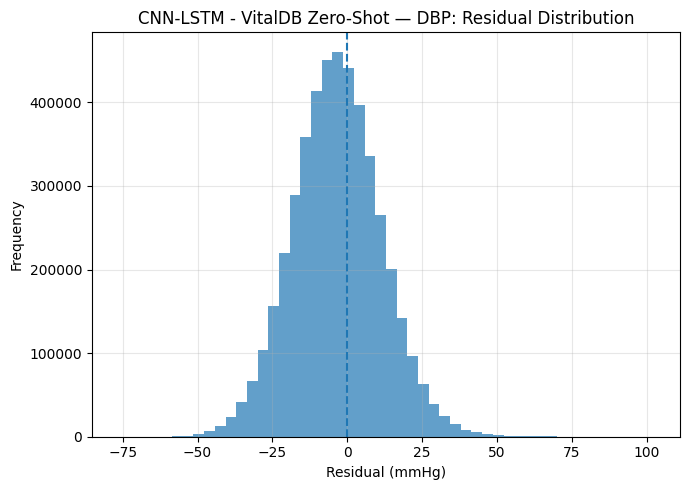

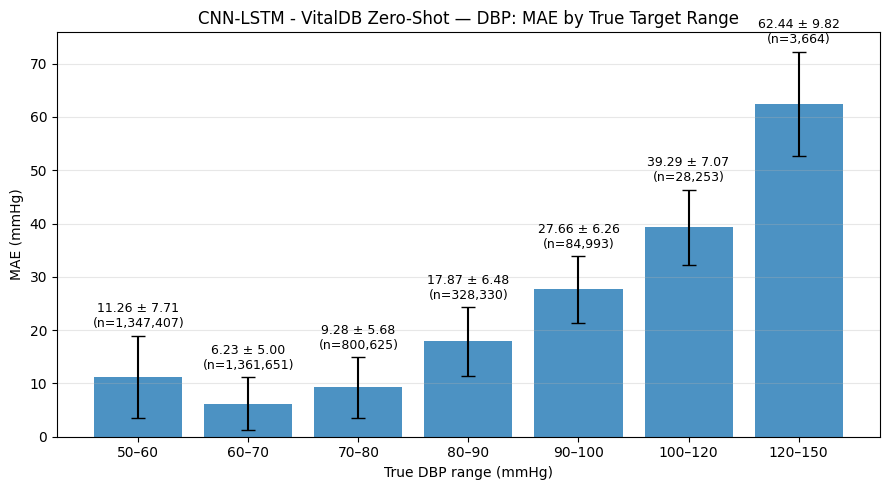

In [7]:
results_cnn_lstm_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_cnn_lstm, base_dir=BASE_DIR, batch_size=256 )

####

Device: cuda
X_train: torch.Size([417030, 1, 625])
y_train: torch.Size([417030, 2])
X_val: torch.Size([52650, 1, 625])
y_val: torch.Size([52650, 2])
X_test: torch.Size([52863, 1, 625])
y_test: torch.Size([52863, 2])
Epoch 01/50 | Train Loss: 981.2637 | Val Loss: 247.5420 | Train SBP RMSE: 39.685 | Train DBP RMSE: 19.687 | Val SBP RMSE: 19.597 | Val DBP RMSE: 10.538 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 214.0176 | Val Loss: 214.9286 | Train SBP RMSE: 18.126 | Train DBP RMSE: 9.975 | Val SBP RMSE: 18.202 | Val DBP RMSE: 9.927 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 188.7619 | Val Loss: 191.8573 | Train SBP RMSE: 17.053 | Train DBP RMSE: 9.313 | Val SBP RMSE: 17.288 | Val DBP RMSE: 9.210 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 170.5913 | Val Loss: 184.8581 | Train SBP RMSE: 16.177 | Train DBP RMSE: 8.915 | Val SBP RMSE: 16.990 | Val DBP RMSE: 9.004 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 156.6854 | Val Loss: 197.4057 | Train SBP RMSE: 15.448 | Train DBP RMSE: 8.644 | Val SBP RMSE: 1

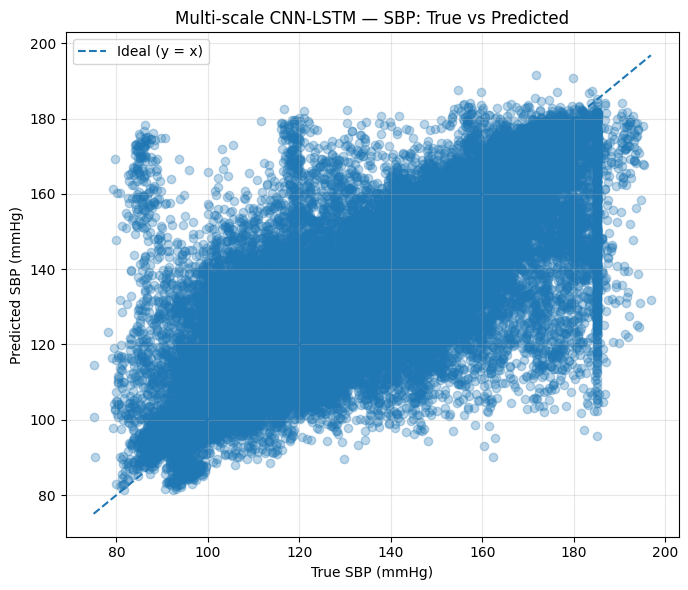

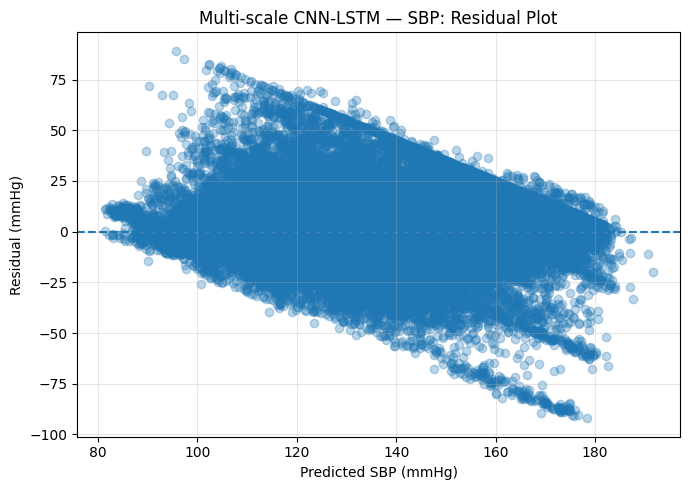

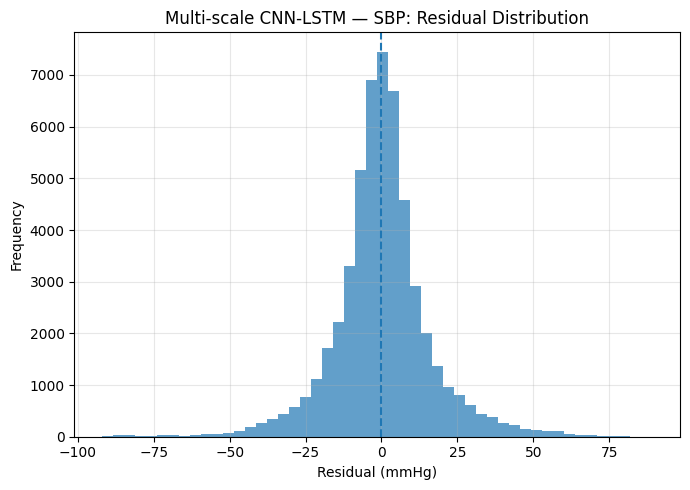

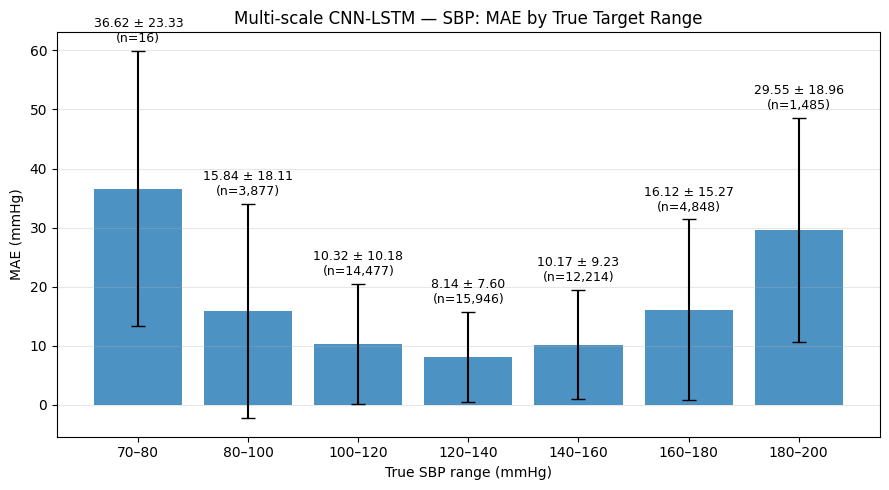

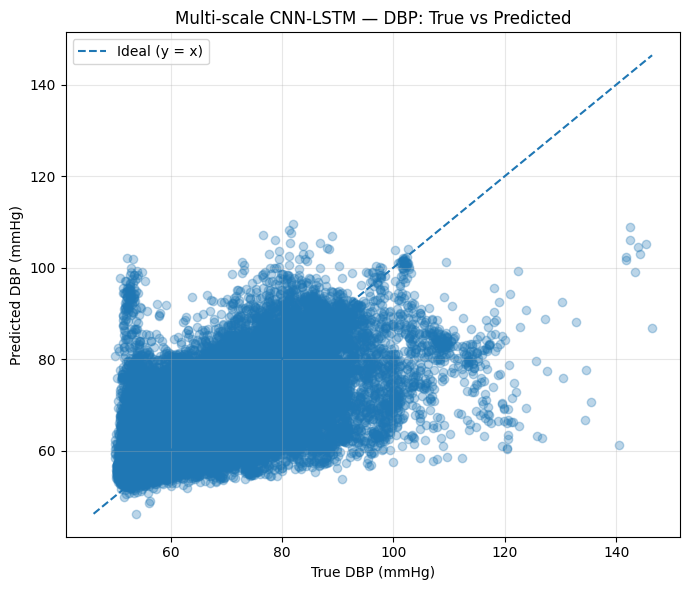

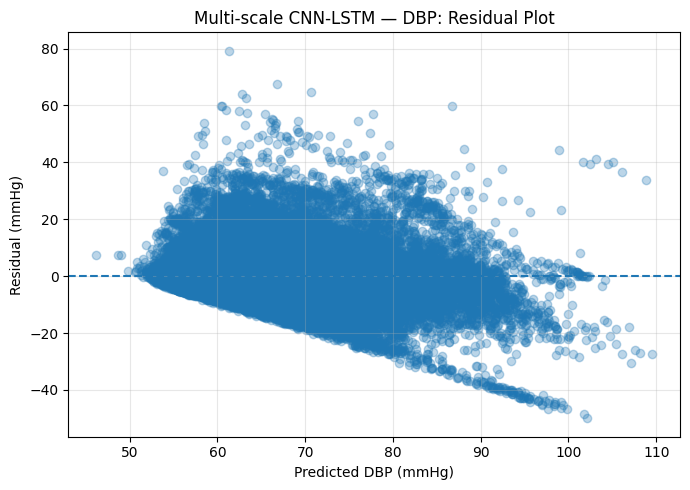

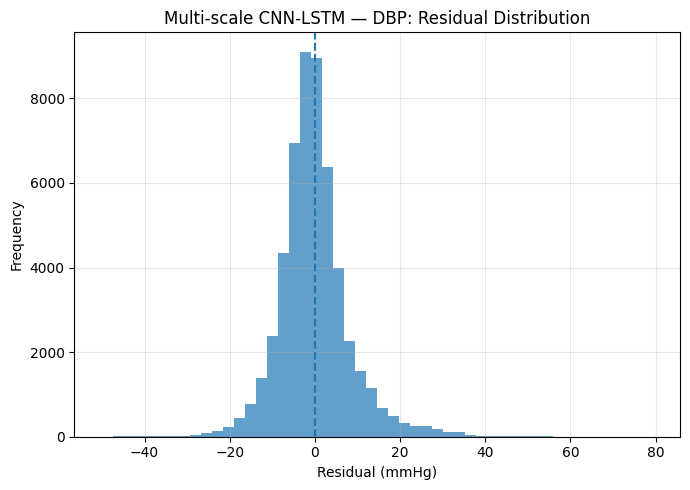

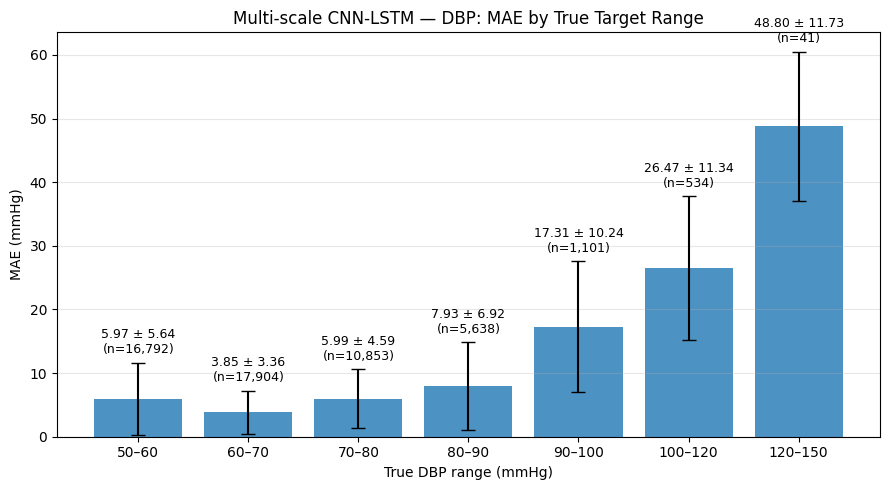

In [8]:
model_multiscale, results_multiscale = train_multiscale_cnn_lstm( 
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    X_test=X_test,
     y_test=y_test, 
     batch_size=256, 
     epochs=50, 
     lr=1e-3, 
     patience=10 )


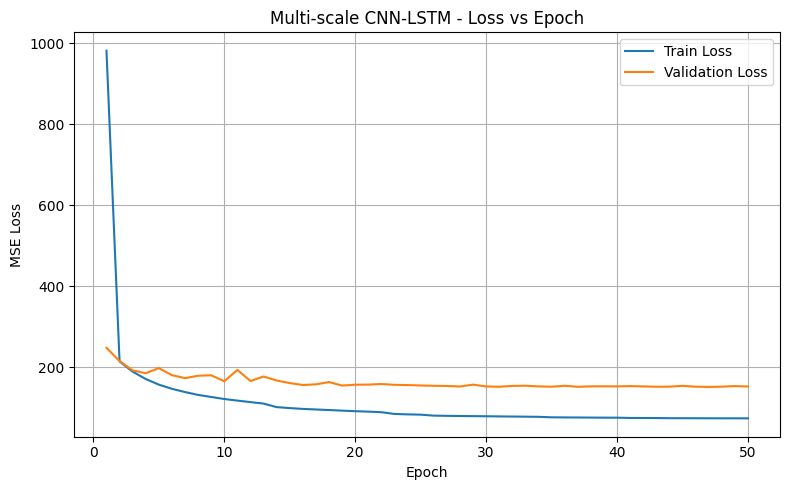

In [9]:
plot_loss_vs_epoch( results_multiscale["history"], model_name="Multi-scale CNN-LSTM" )

Number of VitalDB cases: 1961


CNN-LSTM VitalDB prediction: 100%|██████████| 1961/1961 [03:08<00:00, 10.43case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.9067
MSE : 671.1597
R²  : -0.5752
MAE : 20.6133

DBP
RMSE: 14.9023
MSE : 222.0788
R²  : -0.3644
MAE : 11.7592


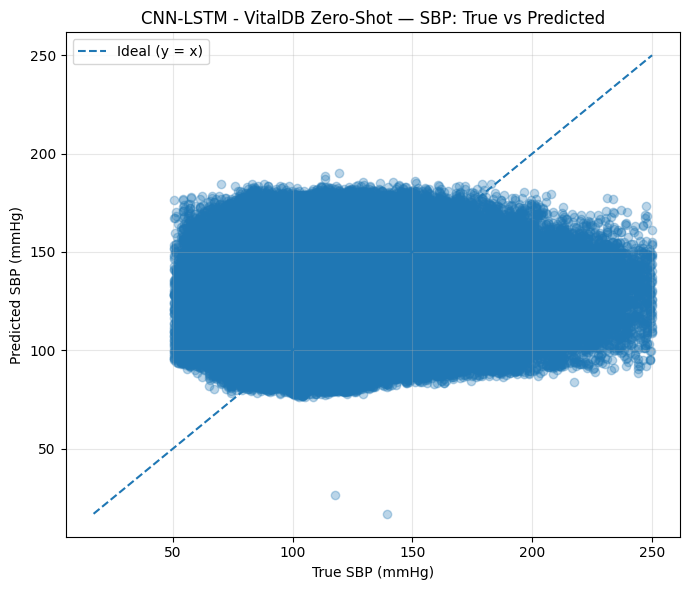

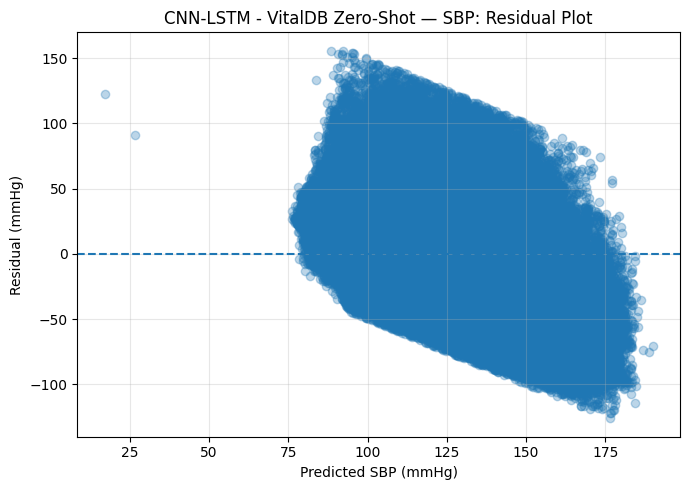

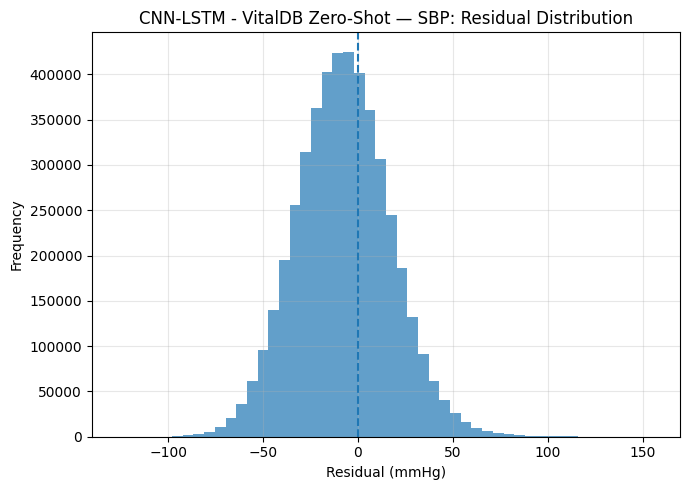

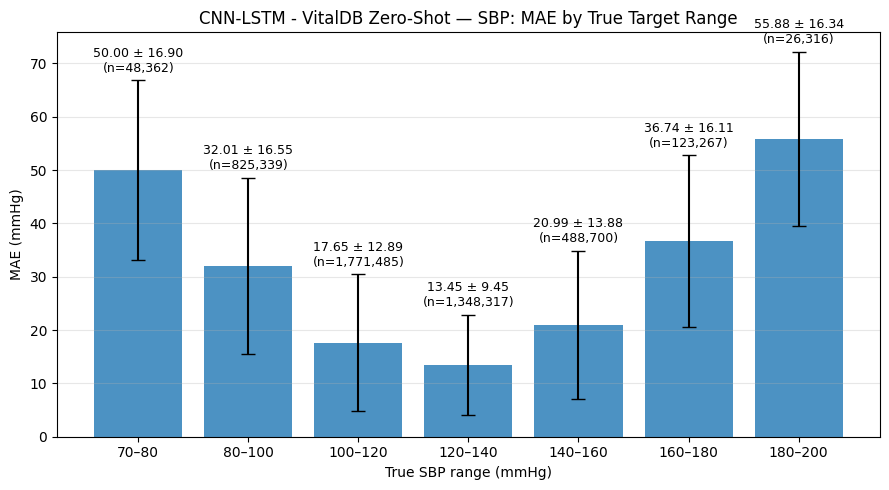

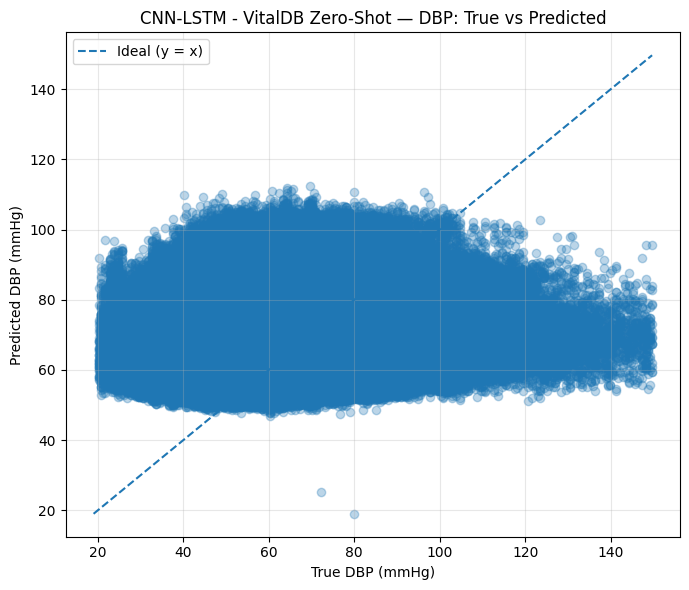

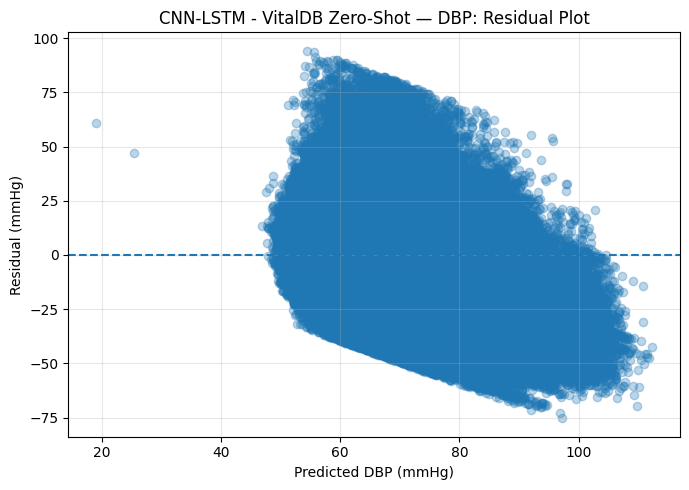

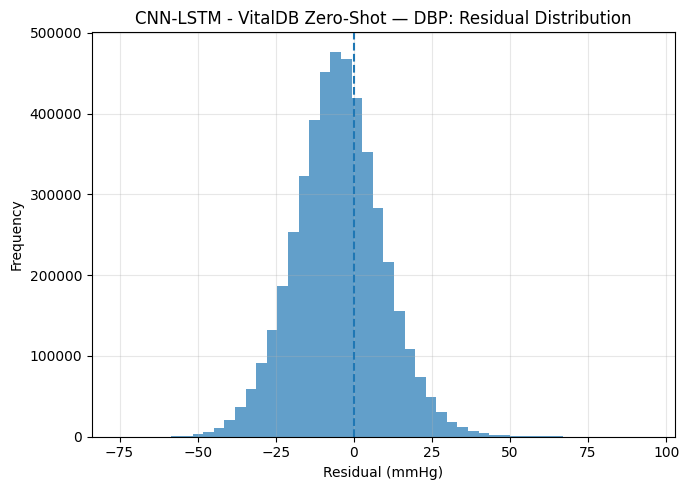

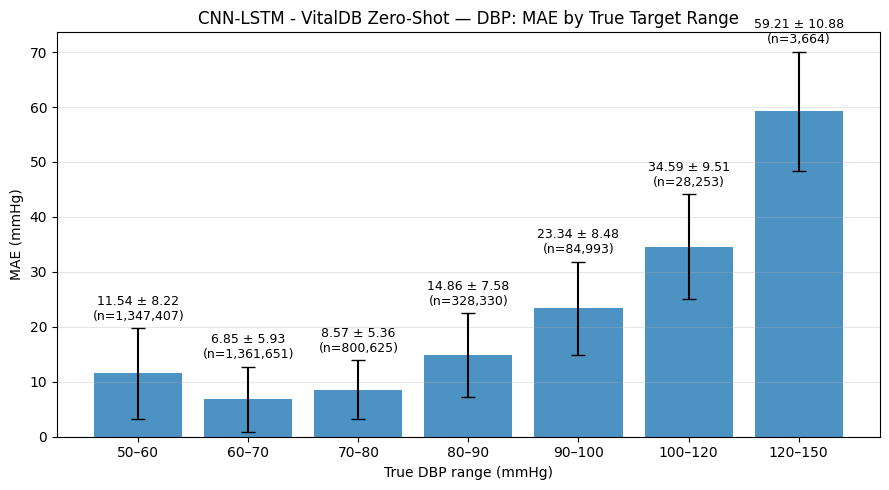

In [10]:
results_multiscale_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_multiscale, base_dir=BASE_DIR, batch_size=256 )

####

In [11]:
model_attention, results_attention = train_cnn_lstm_attention(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

Epoch 01/50 | Train Loss: 929.5740 | Val Loss: 272.4226 | Train RMSE SBP/DBP: 38.80/18.81 | Val RMSE SBP/DBP: 20.21/11.68
Epoch 02/50 | Train Loss: 312.2370 | Val Loss: 589.6257 | Train RMSE SBP/DBP: 21.99/11.88 | Val RMSE SBP/DBP: 29.51/17.55
Epoch 03/50 | Train Loss: 212.1863 | Val Loss: 654.4751 | Train RMSE SBP/DBP: 17.82/10.34 | Val RMSE SBP/DBP: 31.22/18.29
Epoch 04/50 | Train Loss: 183.5644 | Val Loss: 667.7744 | Train RMSE SBP/DBP: 16.35/9.99 | Val RMSE SBP/DBP: 31.73/18.14
Epoch 05/50 | Train Loss: 162.2871 | Val Loss: 534.0152 | Train RMSE SBP/DBP: 15.34/9.44 | Val RMSE SBP/DBP: 28.44/16.10
Epoch 06/50 | Train Loss: 142.6419 | Val Loss: 677.7962 | Train RMSE SBP/DBP: 14.35/8.91 | Val RMSE SBP/DBP: 32.31/17.66
Epoch 07/50 | Train Loss: 135.3022 | Val Loss: 648.8914 | Train RMSE SBP/DBP: 13.96/8.71 | Val RMSE SBP/DBP: 31.75/17.03
Epoch 08/50 | Train Loss: 130.1030 | Val Loss: 776.1297 | Train RMSE SBP/DBP: 13.68/8.55 | Val RMSE SBP/DBP: 34.80/18.47
Epoch 09/50 | Train Loss: 125

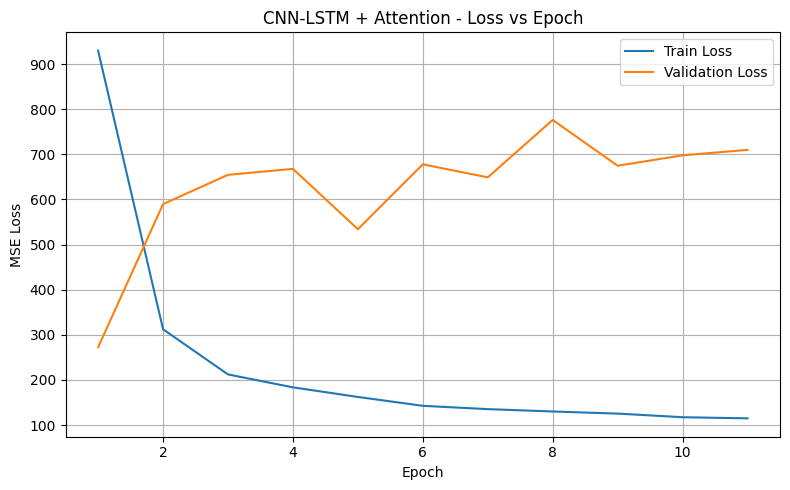

In [12]:
plot_loss_vs_epoch(
    results_attention["history"],
    model_name="CNN-LSTM + Attention"
)

Number of VitalDB cases: 1961


CNN-LSTM VitalDB prediction: 100%|██████████| 1961/1961 [02:22<00:00, 13.73case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 22.5495
MSE : 508.4814
R²  : -0.1934
MAE : 17.7797

DBP
RMSE: 13.2668
MSE : 176.0080
R²  : -0.0814
MAE : 10.3646


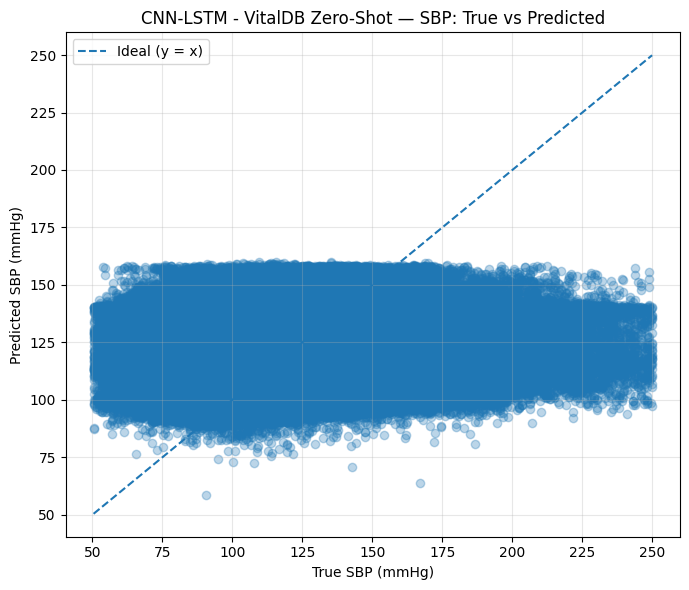

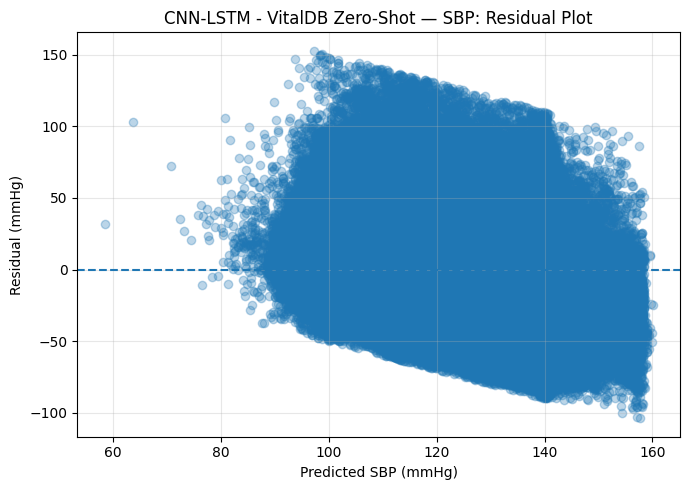

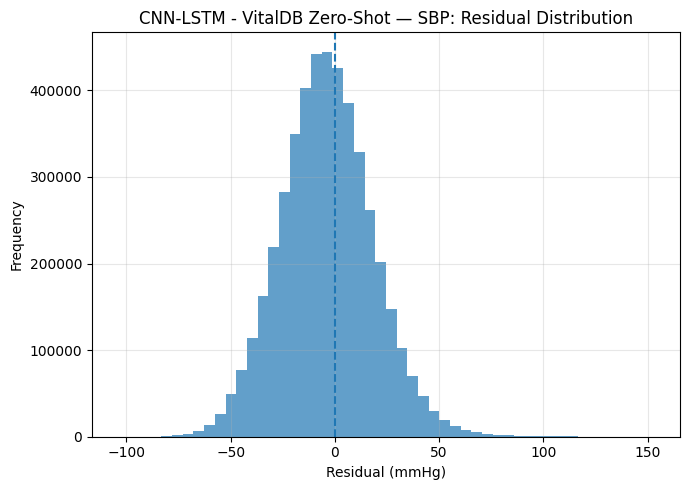

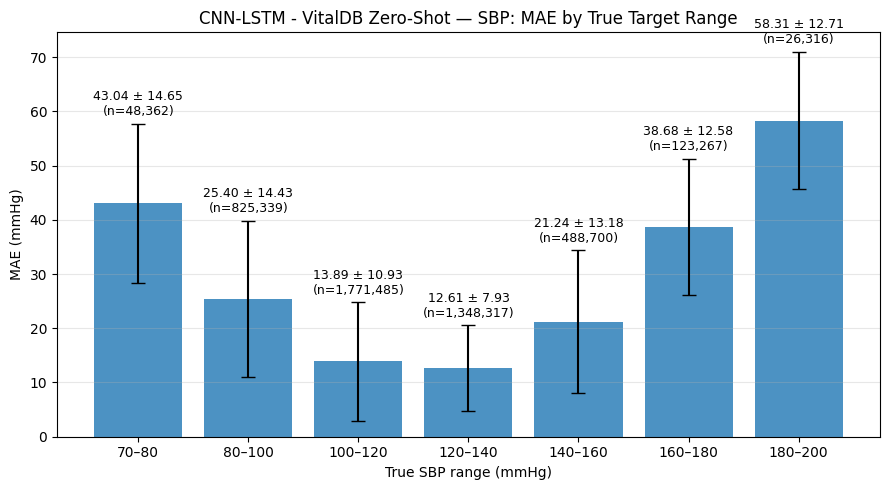

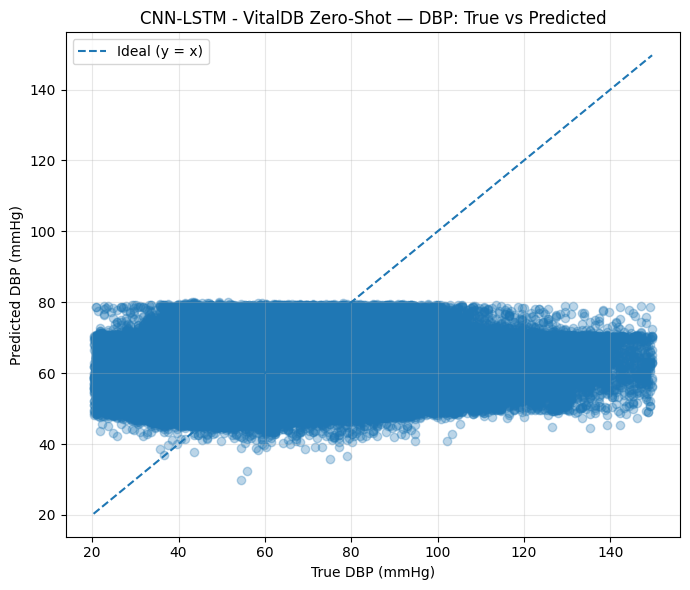

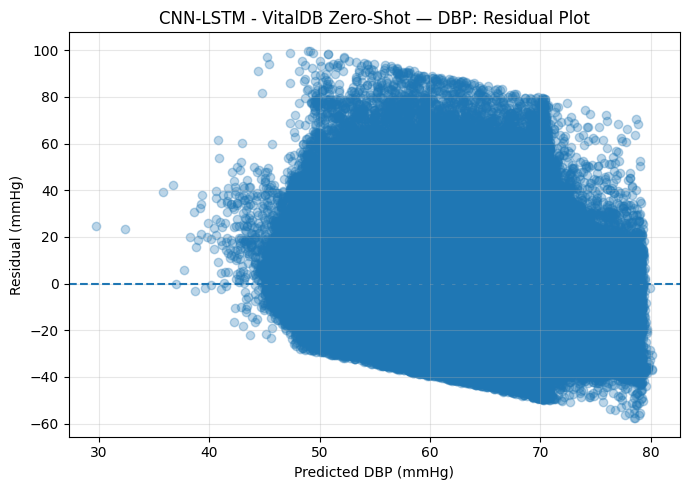

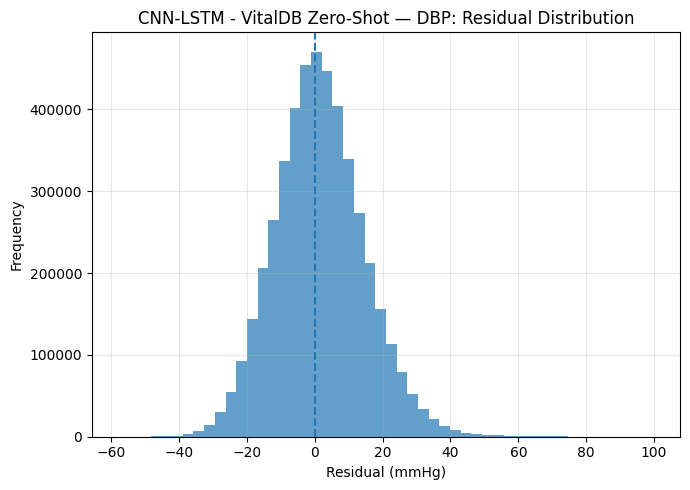

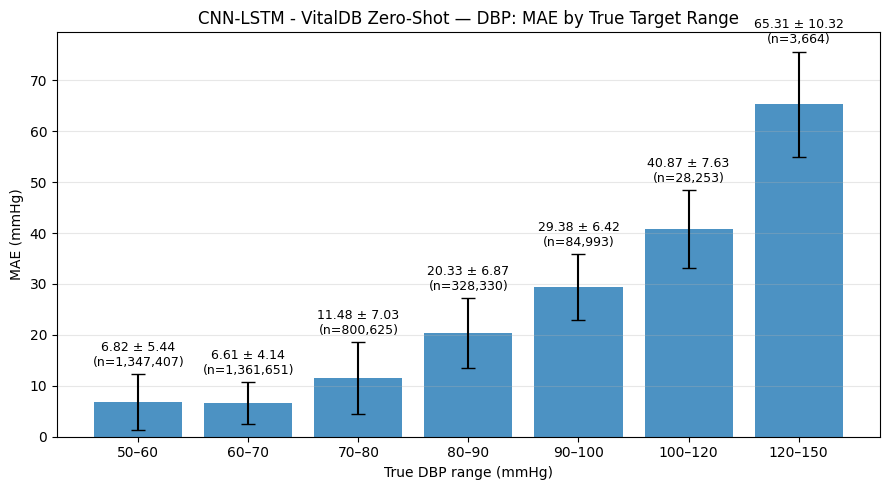

In [13]:

results_attention_vitaldb = evaluate_cnn_lstm_vitaldb(
    model=model_attention,
    base_dir=BASE_DIR,
    batch_size=256
)